# Phase 3 Analyse, Visualise & Report

----------------------------------------------------------------------------------------------------------------------------------------------------------------

In [33]:
from google.colab import files
files.upload()


Saving Untitled27 (1).ipynb to Untitled27 (1) (1).ipynb


{'Untitled27 (1) (1).ipynb': b'{\n  "nbformat": 4,\n  "nbformat_minor": 0,\n  "metadata": {\n    "colab": {\n      "provenance": []\n    },\n    "kernelspec": {\n      "name": "python3",\n      "display_name": "Python 3"\n    },\n    "language_info": {\n      "name": "python"\n    }\n  },\n  "cells": [\n    {\n      "cell_type": "markdown",\n      "source": [\n        "# Phase 2  Engineer & Transform Features"\n      ],\n      "metadata": {\n        "id": "rSlBgYJJc5xG"\n      }\n    },\n    {\n      "cell_type": "markdown",\n      "source": [\n        "----------------------------------------------------------------------------------------------------------------------------------------------------------------"\n      ],\n      "metadata": {\n        "id": "P0eI42_Idlnt"\n      }\n    },\n    {\n      "cell_type": "code",\n      "execution_count": 2,\n      "metadata": {\n        "colab": {\n          "base_uri": "https://localhost:8080/",\n          "height": 1000\n        },\n      

In [34]:
import os
import pandas as pd
import kagglehub
def Load_data():
    path = kagglehub.dataset_download("prevek18/ames-housing-dataset")
    file_path = os.path.join(path, "AmesHousing.csv")
    df = pd.read_csv(file_path)
    print(df.head())
    return df
df = Load_data()

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import dot
from numpy.linalg import norm
from sklearn.preprocessing import StandardScaler

See how house prices and area vary and also to know if there are outliers or skewed

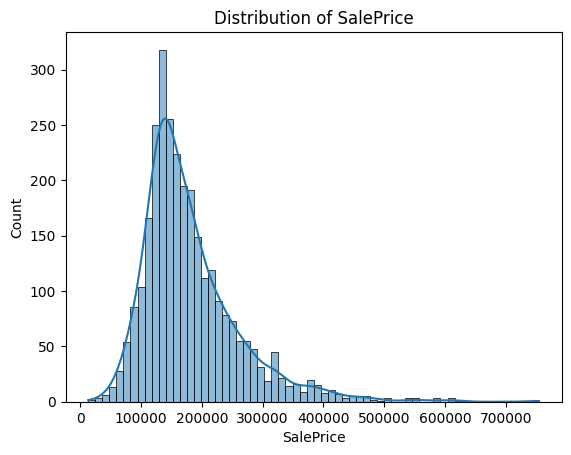

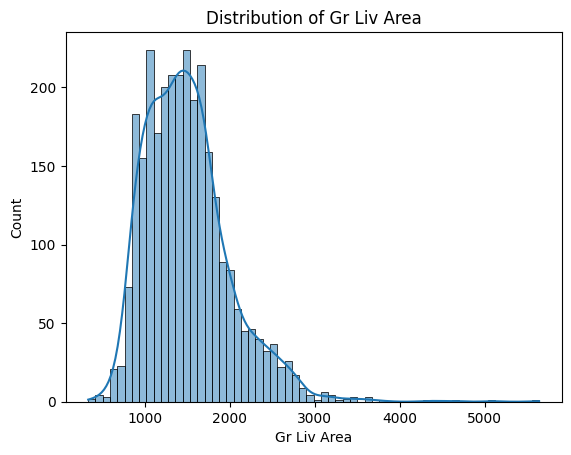

In [36]:
for col in["SalePrice", "Gr Liv Area"]:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

We divided the houses into groups then we see how the price changes according to age

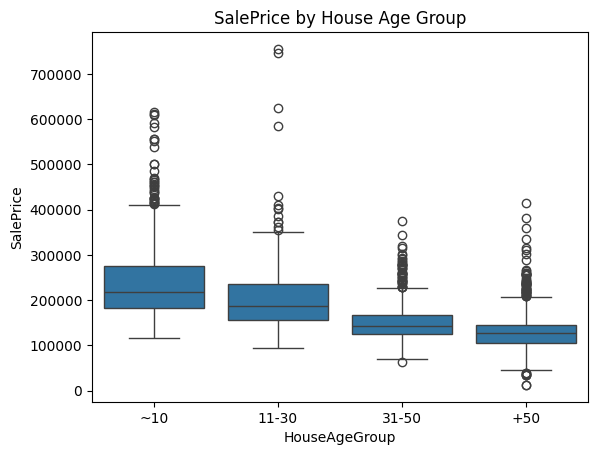

In [37]:
df["HouseAge"]=df["Yr Sold"]-df["Year Built"]
df["HouseAgeGroup"]=pd.cut(df["HouseAge"], bins=[0,10,30,50,100], labels=["~10","11-30","31-50","+50"])
sns.boxplot(x="HouseAgeGroup", y="SalePrice", data=df)
plt.title("SalePrice by House Age Group")
plt.show()

See which columns have strong effect on price and we made a plot to show us

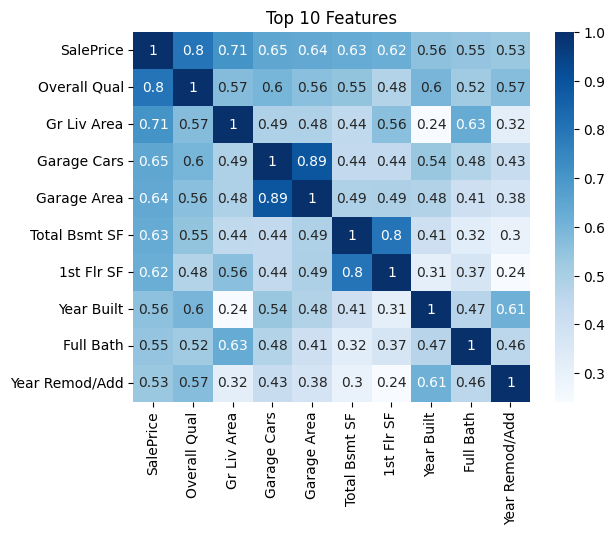

In [38]:
numeric=df.select_dtypes(include=np.number).columns
Top10Corr= df[numeric].corr()["SalePrice"].sort_values(ascending=False).head(10).index
sns.heatmap(df[Top10Corr].corr(), annot=True, cmap="Blues")
plt.title("Top 10 Features")
plt.show()

The more the area or quality the higher the price

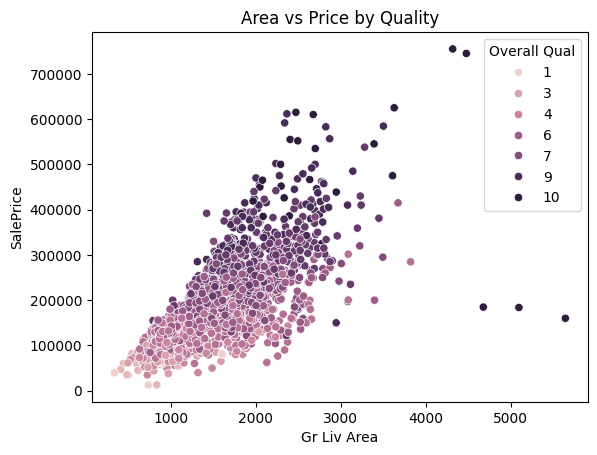

In [39]:
sns.scatterplot(x="Gr Liv Area", y="SalePrice", hue="Overall Qual", data=df)
plt.title("Area vs Price by Quality")
plt.show()

In [40]:
df.groupby("HouseAgeGroup")["SalePrice"].mean()

/tmp/ipykernel_5257/1920506133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("HouseAgeGroup")["SalePrice"].mean()


,SalePrice
HouseAgeGroup,
~10,240544.375821
11-30,205159.767442
31-50,150227.624661
+50,130195.260976


Calculated mean and standard deviation to get the Z_score

In [41]:
Target= df["SalePrice"].values
MeanVal= np.sum(Target)/len(Target)
StdVal= np.sqrt(np.sum((Target-MeanVal)**2)/len(Target))
print(MeanVal)
print(StdVal)

180796.0600682594
79873.05865192253


In [42]:
Z_score= (Target-MeanVal)/StdVal
print(Z_score[:5])

[ 0.42822875 -0.94895652 -0.11012549  0.79130487  0.11398011]


Make sure the calculation we did above matches StandardScaler from sklearn

In [43]:
Target=df["SalePrice"].values
MeanVal=np.mean(Target)
StdVal=np.std(Target)
Z_score=(Target-MeanVal)/StdVal
print("Differences |Manual vs StandardScaler| :")
scaler=StandardScaler()
SalePrice_scaled=scaler.fit_transform(Target.reshape(-1,1))
for i in range(5):
    print(Z_score[i]- SalePrice_scaled[i][0])

Differences |Manual vs StandardScaler| :
0.0
0.0
0.0
0.0
0.0


Calculated mean and standard deviation to get the Z_score

In [44]:
High= df[df["SalePrice"]==df["SalePrice"].max()][["Gr Liv Area", "Overall Qual"]].values.flatten()
Low= df[df["SalePrice"]==df["SalePrice"].min()][["Gr Liv Area", "Overall Qual"]].values.flatten()
CosSim= dot(High, Low)/(norm(High)*norm(Low))
print(CosSim)

0.9999999962254531


Here we checked how much fraction of good houses with price above half million plus7

In [45]:
HighQuality= df[df["Overall Qual"]>=7]
Frac= (HighQuality["SalePrice"]>500000).mean()
print(Frac)

0.015596330275229359


Bonus

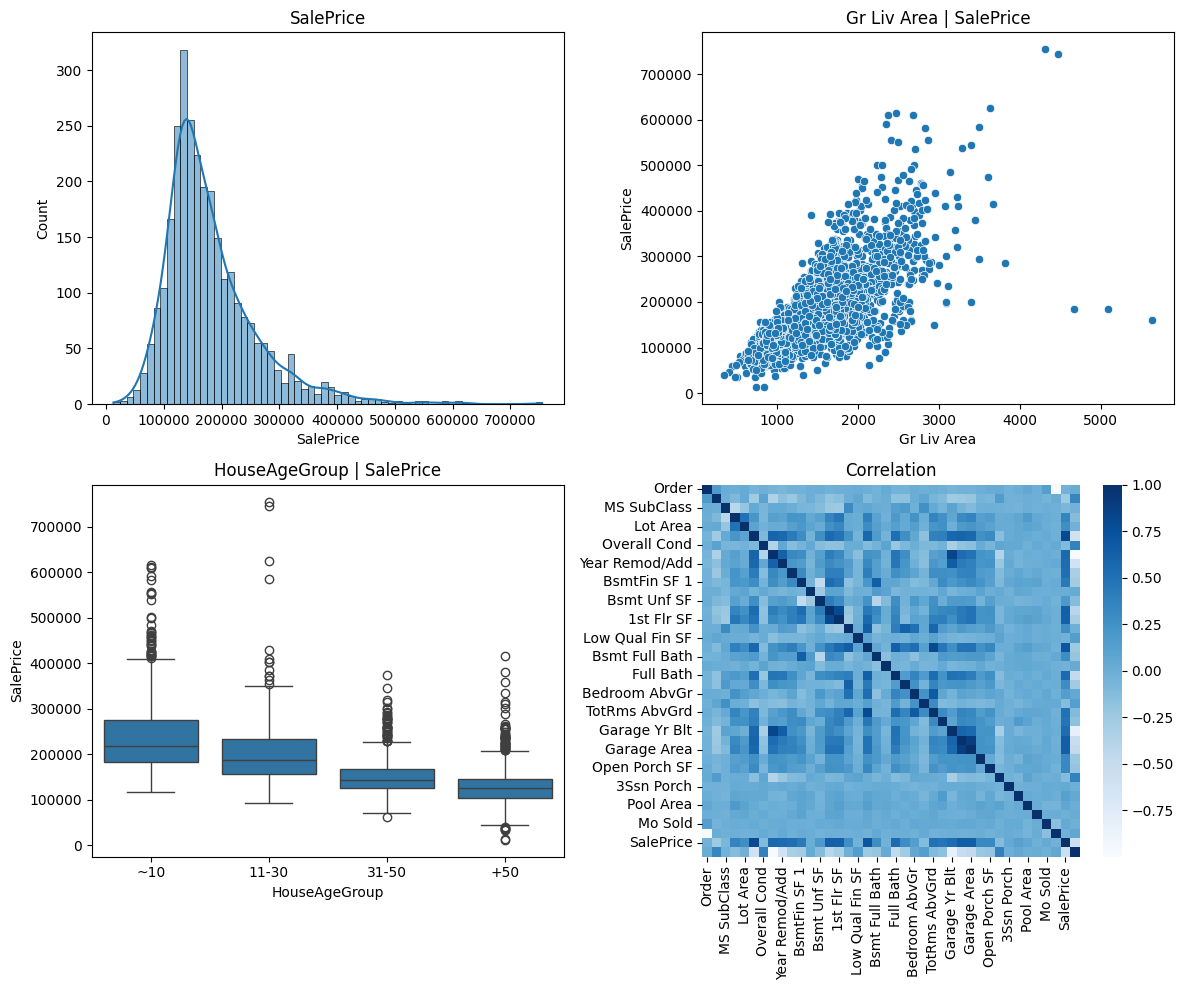

In [46]:
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.histplot(df["SalePrice"],kde=True)
plt.title("SalePrice")

plt.subplot(2,2,2)
sns.scatterplot(x="Gr Liv Area",y="SalePrice",data=df)
plt.title("Gr Liv Area | SalePrice")

plt.subplot(2,2,3)
sns.boxplot(x="HouseAgeGroup",y="SalePrice",data=df)
plt.title("HouseAgeGroup | SalePrice")

plt.subplot(2,2,4)
sns.heatmap(df.corr(numeric_only=True),cmap="Blues")
plt.title("Correlation")

plt.tight_layout()
plt.show()